In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("../data/raw/vietnam_weather_2023_complete.csv")

In [32]:
df['rain_sum'].describe()

count    48216.000000
mean         5.979915
std         11.733066
min          0.000000
25%          0.000000
50%          1.500000
75%          7.300000
max        287.700000
Name: rain_sum, dtype: float64

# Datapreprocess

In [3]:
df['weather_code'].value_counts()

weather_code
51    11281
3     10183
63     9630
53     5392
61     5287
65     2361
55     2003
2      1107
1       639
0       333
Name: count, dtype: int64

In [4]:
def group_weather_codes(code):
    if code in [0, 1, 2, 3]:
        return 0
    elif code in [45, 48]:
        return 2
    elif code in [51, 53, 55, 61, 63, 65, 80, 81, 82]:
        return 1
    elif code in [95, 96, 99]:
        return 3
    else:
        return 'Other' # Cho các trường hợp khác nếu có

# Tạo một cột mới chứa các nhóm đã được gom lại
df['weather_code'] = df['weather_code'].apply(group_weather_codes)

In [5]:
df['weather_code'].value_counts()

weather_code
1    35954
0    12262
Name: count, dtype: int64

1. Encoding

In [6]:
col = df.dtypes == 'object'
col = df.columns[col]
col

Index(['city', 'date', 'sunrise', 'sunset'], dtype='object')

In [7]:
df_encode = df.copy()

transform time object from  str to time

In [8]:
df_encode['sunrise'] = pd.to_datetime(df_encode['sunrise']).dt.time
df_encode['sunset'] = pd.to_datetime(df_encode['sunset']).dt.time
df_encode['date'] = pd.to_datetime(df_encode['date'])
df_encode[['sunrise', 'sunset', 'date']]

,sunrise,sunset,date
0,06:33:00,17:26:00,2014-01-01
1,06:34:00,17:27:00,2014-01-02
2,06:34:00,17:27:00,2014-01-03
3,06:34:00,17:28:00,2014-01-04
4,06:35:00,17:29:00,2014-01-05
...,...,...,...
48211,06:10:00,17:40:00,2024-12-27
48212,06:10:00,17:41:00,2024-12-28
48213,06:10:00,17:41:00,2024-12-29
48214,06:11:00,17:42:00,2024-12-30


In [9]:
col_int = df_encode.dtypes == 'int64'
col_int = df_encode.columns[col_int]
df_encode[col_int] = df_encode[col_int].astype('float64')

In [10]:
df_encode['weather_code'] = df['weather_code'].astype("int64")

2. Outlier

2.1. Scaler

In [11]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
import joblib
cols_num = df_encode.select_dtypes(include=['float64', 'int64']).columns
cols_to_exclude = ['latitude', 'longitude', 'weather_code', "rain_sum", "precipitation_hours"]
cols_num = [c for c in cols_num if c not in cols_to_exclude]

def split_data(df, val_year=1):
    years = df['date'].dt.year.unique()
    years.sort() 
    val_years = years[-val_year:]
    train_df = df[~df['date'].dt.year.isin(val_years)].reset_index(drop=True)
    val_df = df[df['date'].dt.year.isin(val_years)].reset_index(drop=True)
    
    return train_df, val_df, val_years

train_df, val_df, val_years_list = split_data(df_encode, val_year=1)
print(f"Train years: {train_df['date'].dt.year.unique()}")
print(f"Val years: {val_years_list}")

scaler = RobustScaler()

train_df[cols_num] = scaler.fit_transform(train_df[cols_num])
val_df[cols_num] = scaler.transform(val_df[cols_num])

df_scaler = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

print("Shape sau khi scale:", df_scaler.shape)
print("Các cột còn lại:", df_scaler.columns.tolist())

joblib.dump(scaler, '../models/scaler/robust_scaler.pkl')

Train years: [2014 2015 2016 2017 2018 2019 2020 2021 2022 2023]
Val years: [2024]
Shape sau khi scale: (48216, 27)
Các cột còn lại: ['city', 'latitude', 'longitude', 'date', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'rain_sum', 'precipitation_hours', 'weather_code', 'sunrise', 'sunset', 'sunshine_duration', 'daylight_duration', 'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'relative_humidity_2m_mean', 'dewpoint_2m_max', 'dewpoint_2m_min', 'dewpoint_2m_mean', 'surface_pressure_mean', 'cloudcover_mean']


['../models/scaler/robust_scaler.pkl']

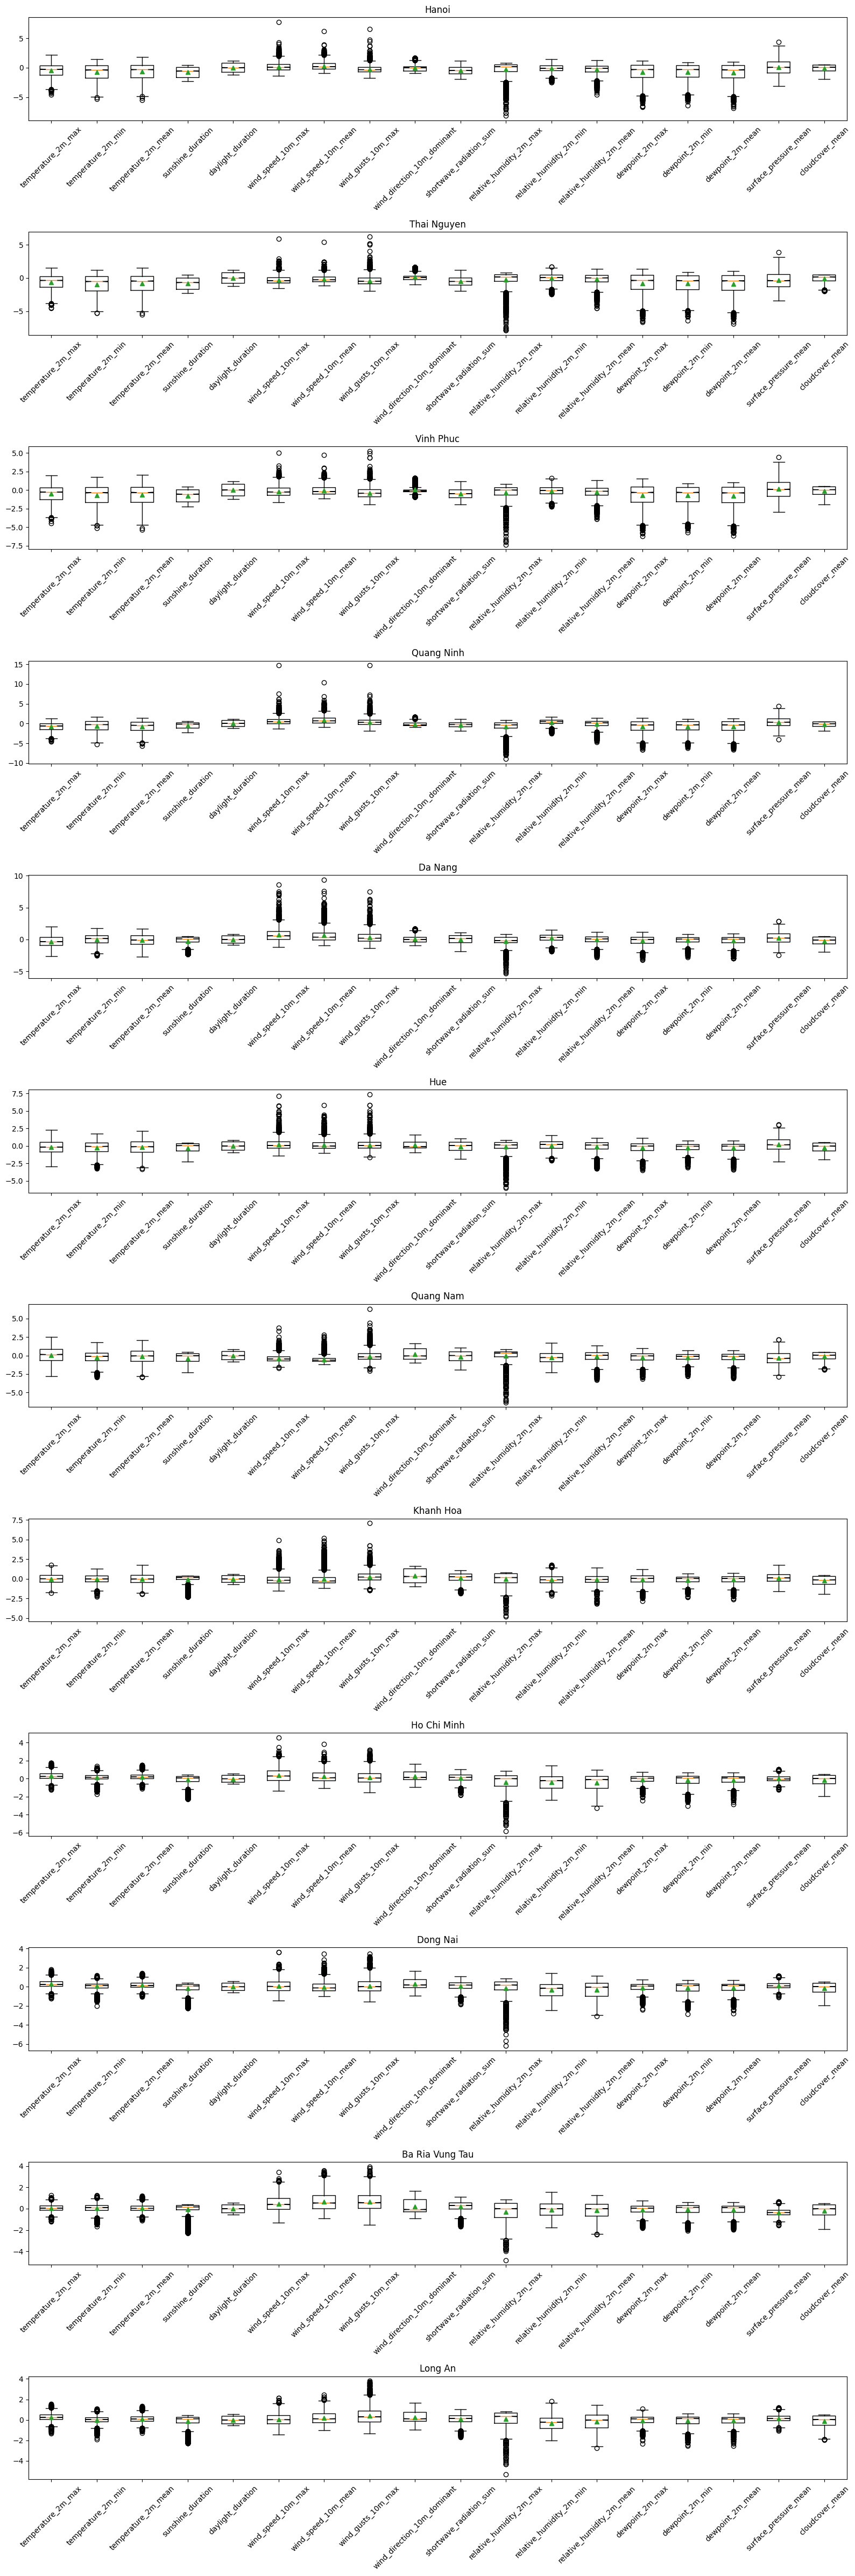

In [12]:
plt.figure(figsize=(16, 48))
cities = df_scaler['city'].unique()
for index, city in enumerate(cities):
    plt.subplot(len(cities), 1, index + 1)
    data = df_scaler[df_scaler['city'] == city][cols_num]
    plt.boxplot([data[c] for c in cols_num], tick_labels=cols_num, showmeans=True, notch=True)
    plt.title(city)
    plt.xticks(rotation=45)
    plt.tight_layout()

2.2. Rolling IQR

In [13]:

outlier = ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
           'rain_sum', 'precipitation_hours', 'sunshine_duration',
           'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_gusts_10m_max', 'shortwave_radiation_sum',
           'relative_humidity_2m_max', 'relative_humidity_2m_min', 'relative_humidity_2m_mean',
           'dewpoint_2m_max', 'dewpoint_2m_min', 'dewpoint_2m_mean',
           'surface_pressure_mean', 'cloudcover_mean']

df_iqr = df_scaler.copy()

def Sliding(data, window_size=7):
    roller = data.rolling(window=window_size, min_periods=1)
    q1 = roller.quantile(0.25)
    q3 = roller.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data_anomaly = data[(data < lower_bound) | (data > upper_bound)]
    return data_anomaly, data.clip(lower=lower_bound, upper=upper_bound)

anomaly_dict = {}
for col in outlier:
    col_anomalies_list = []
    cities = df_iqr['city'].unique()
    for city in cities:
        mask = df_iqr['city'] == city
        city_data = df_iqr.loc[mask, col]
        anomalies, handled_data = Sliding(city_data, window_size=7)   
        df_iqr.loc[mask, col] = handled_data
        if not anomalies.empty:
            col_anomalies_list.append(anomalies)
    if col_anomalies_list:
        anomaly_dict[col] = pd.concat(col_anomalies_list).sort_index()
    else:
        anomaly_dict[col] = pd.Series(dtype=float) # Trống nếu không có anomaly nào

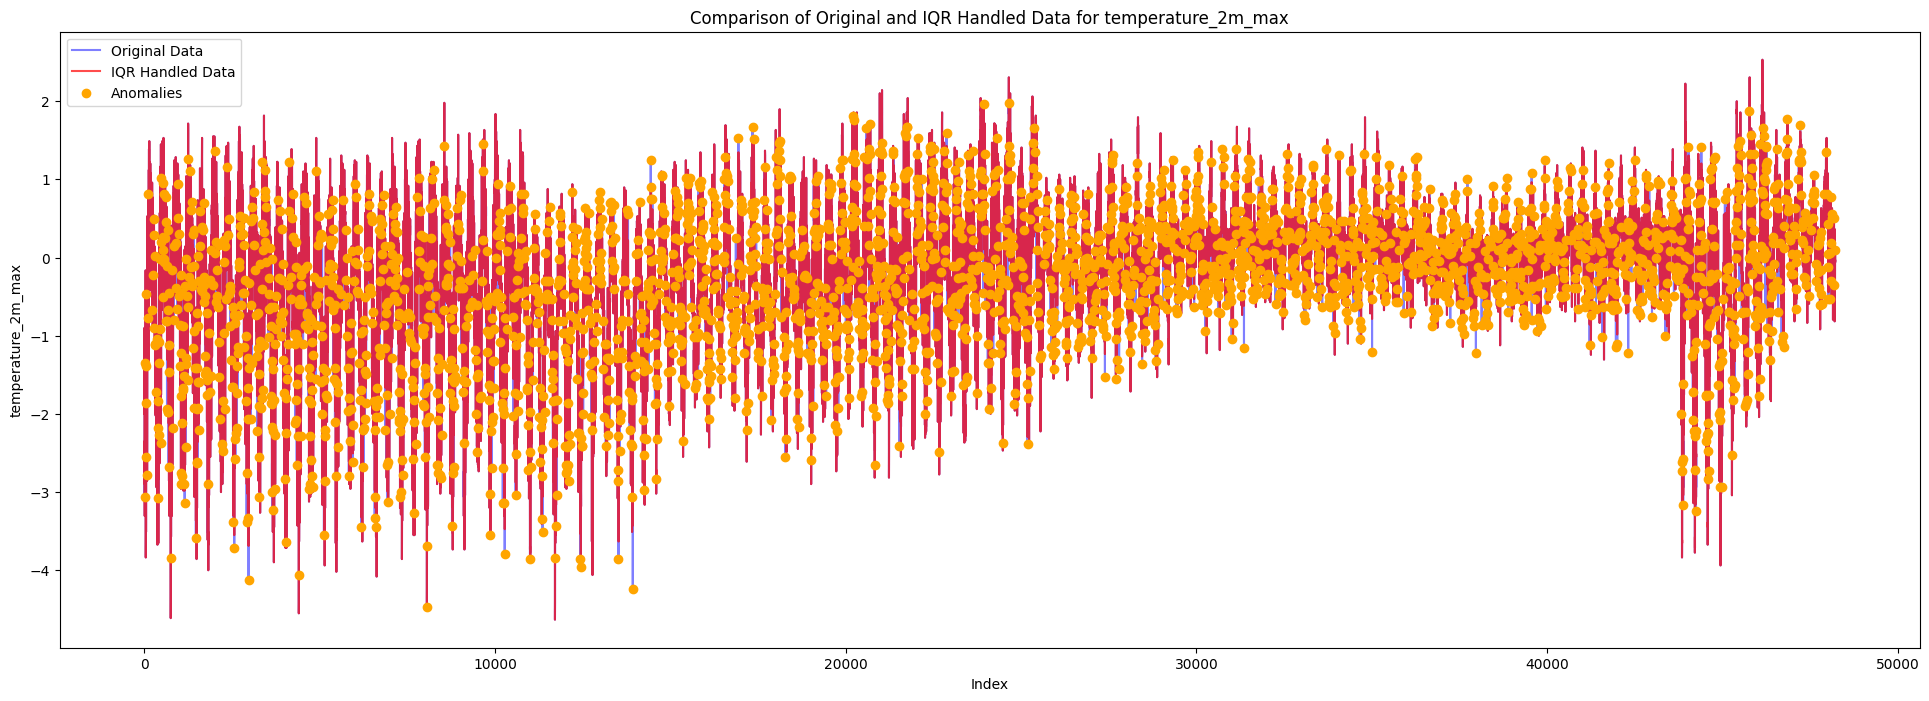

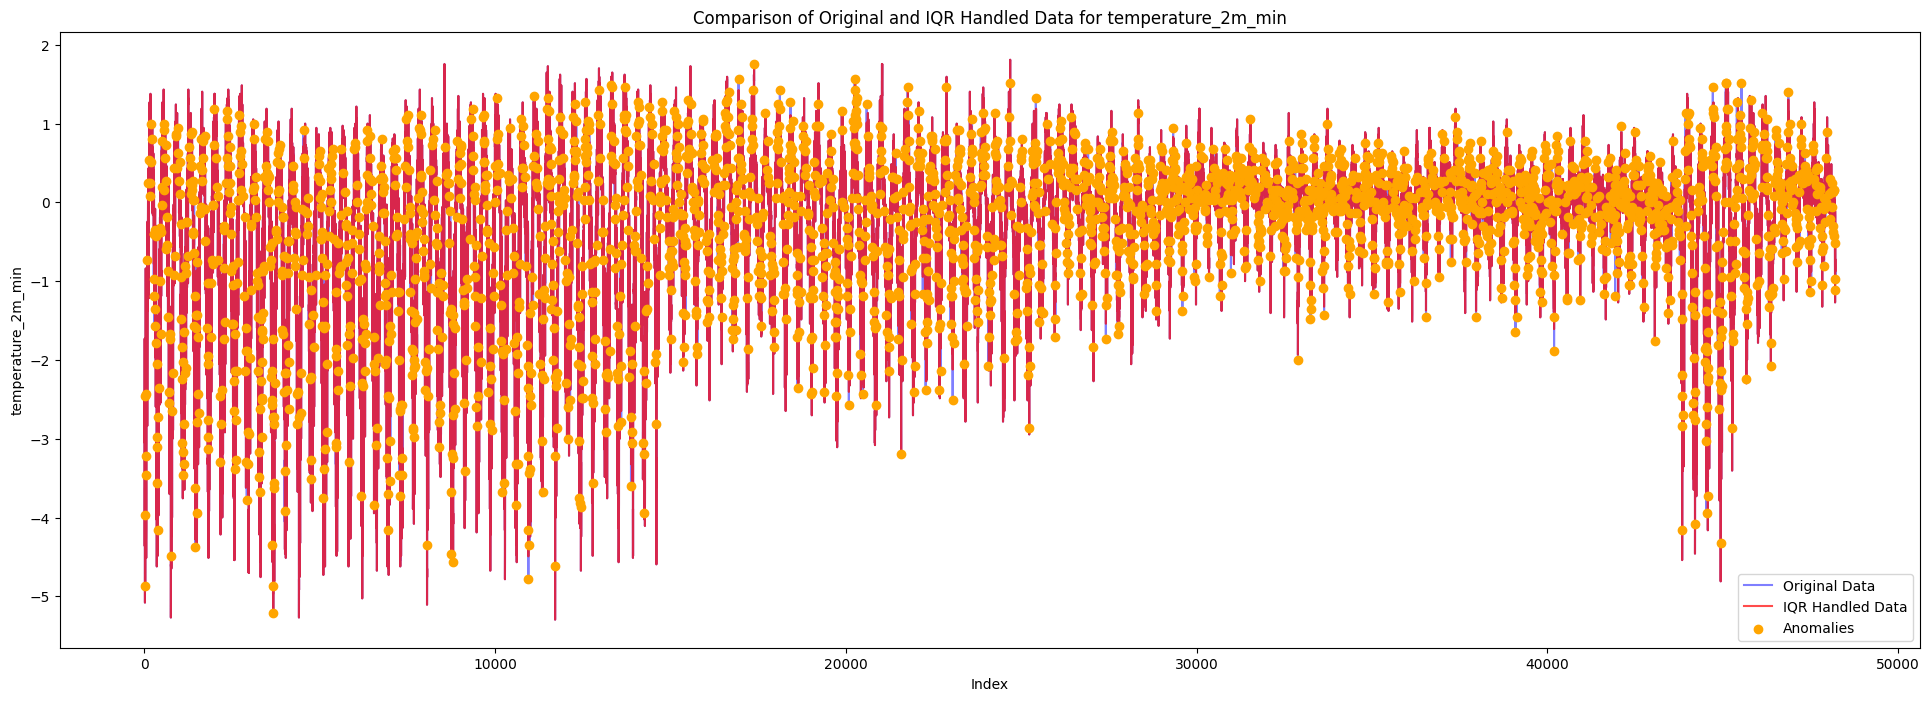

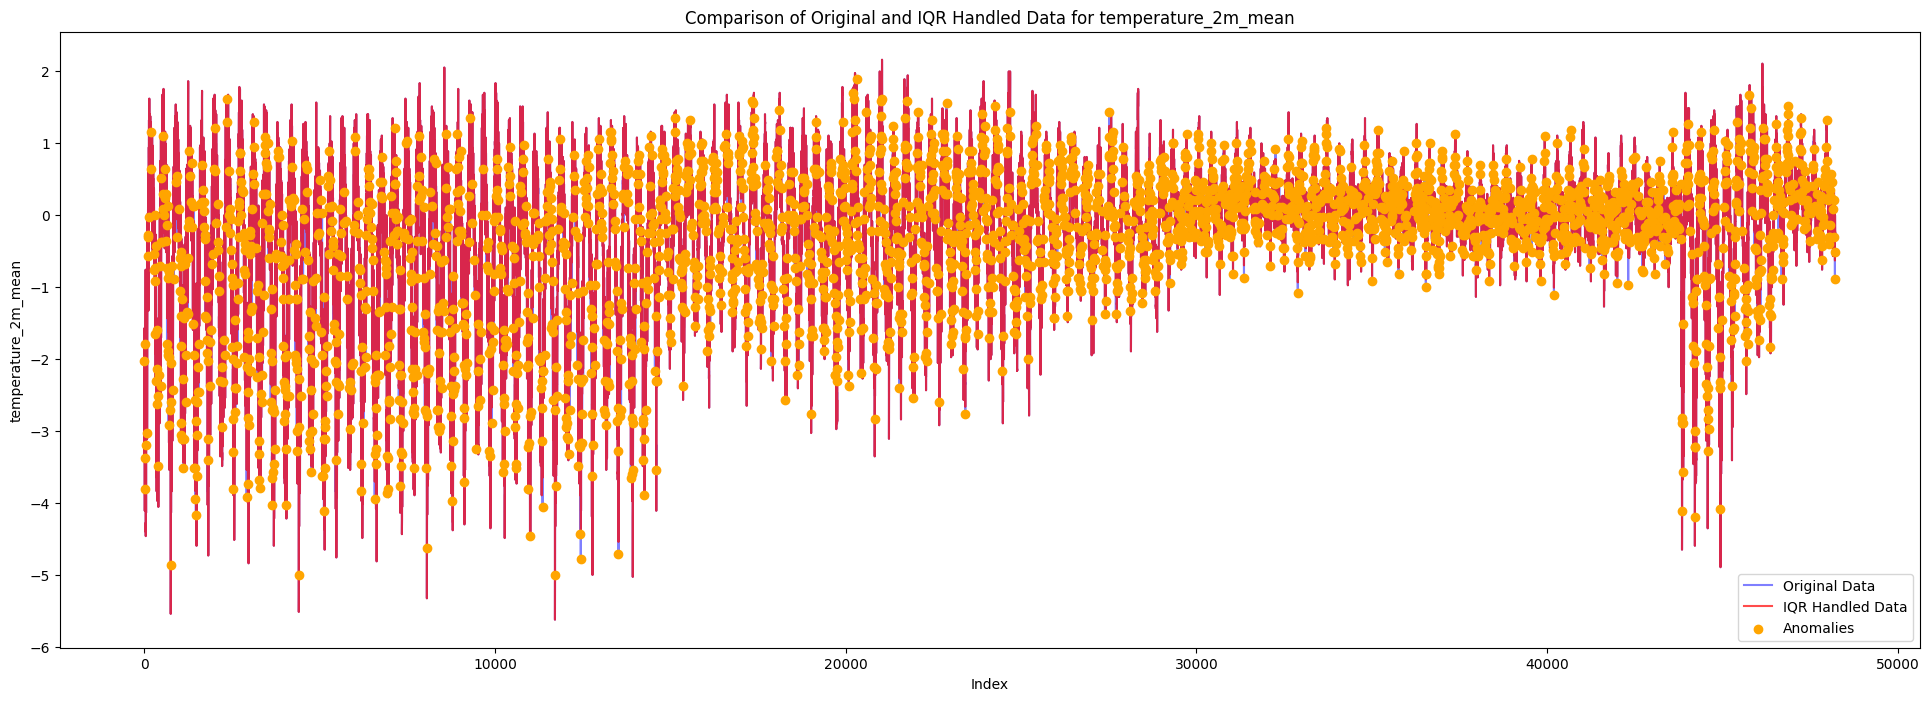

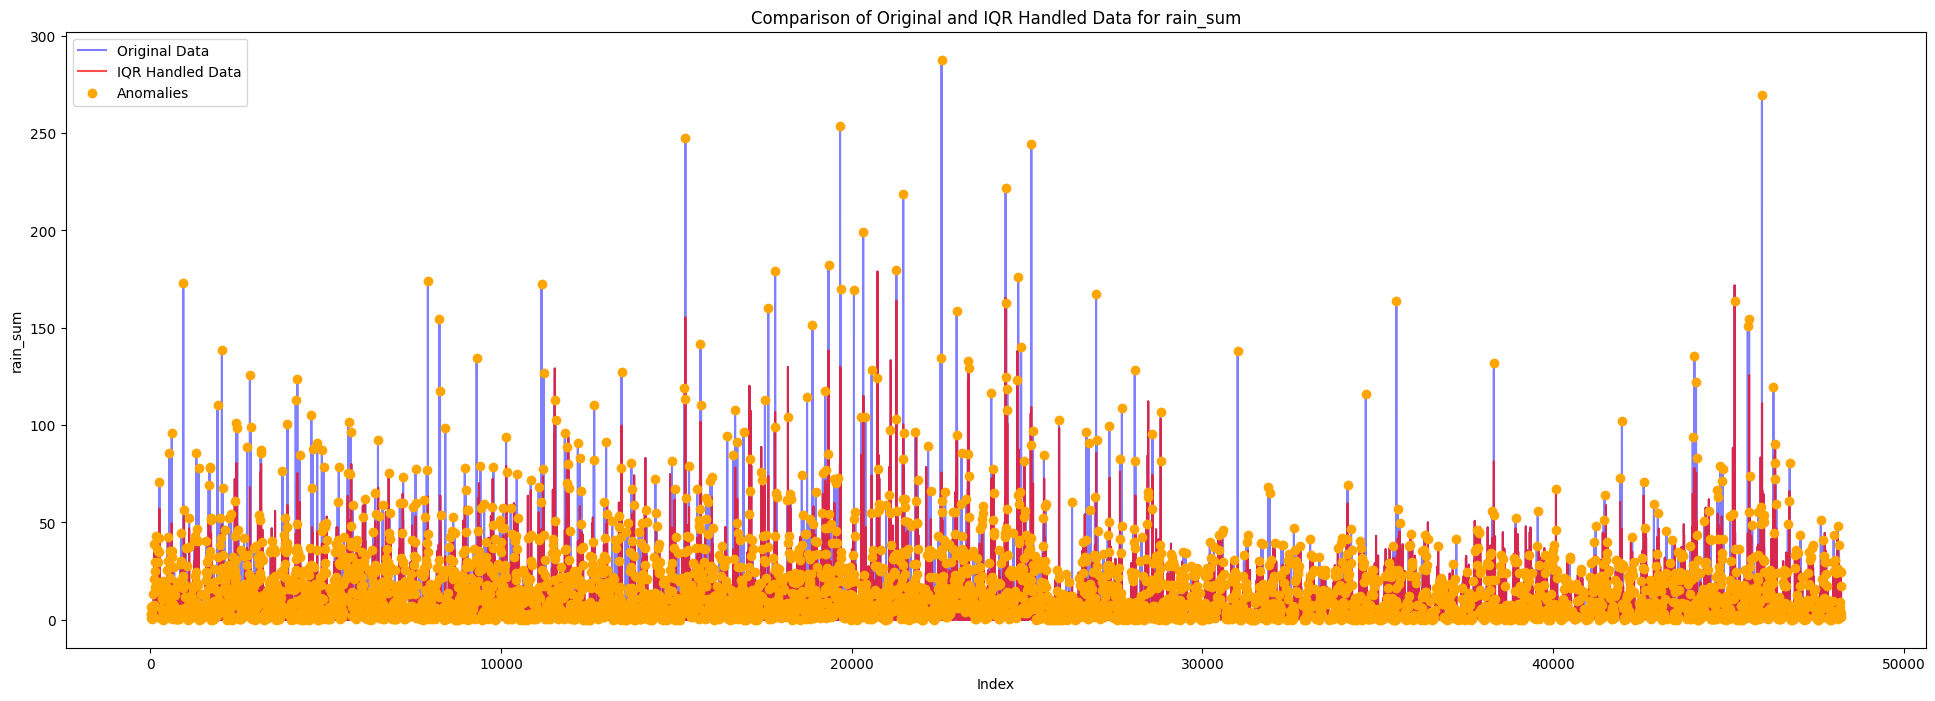

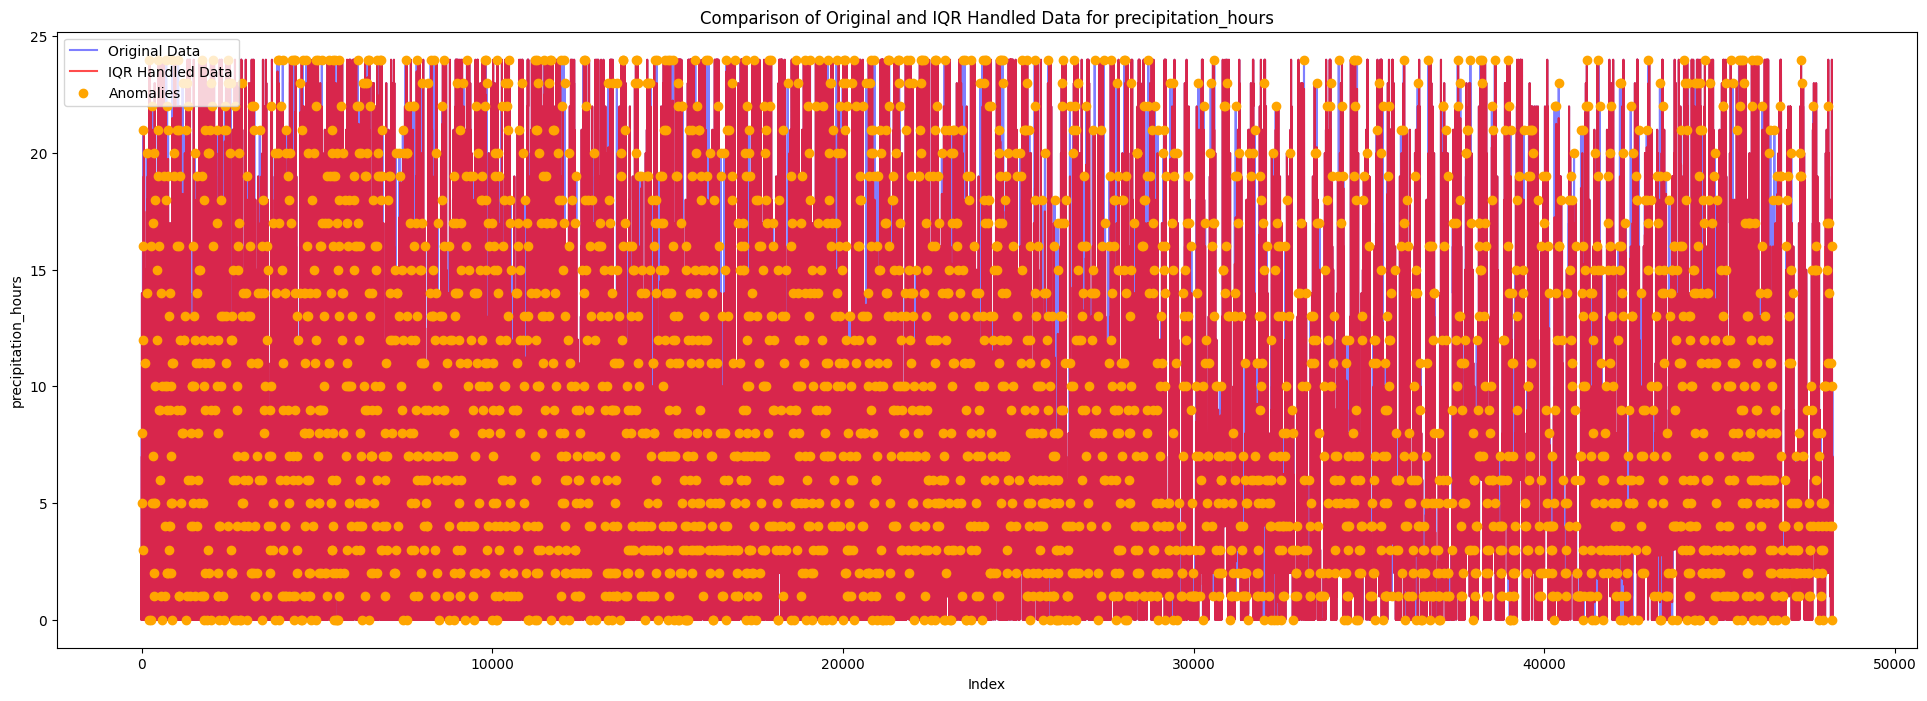

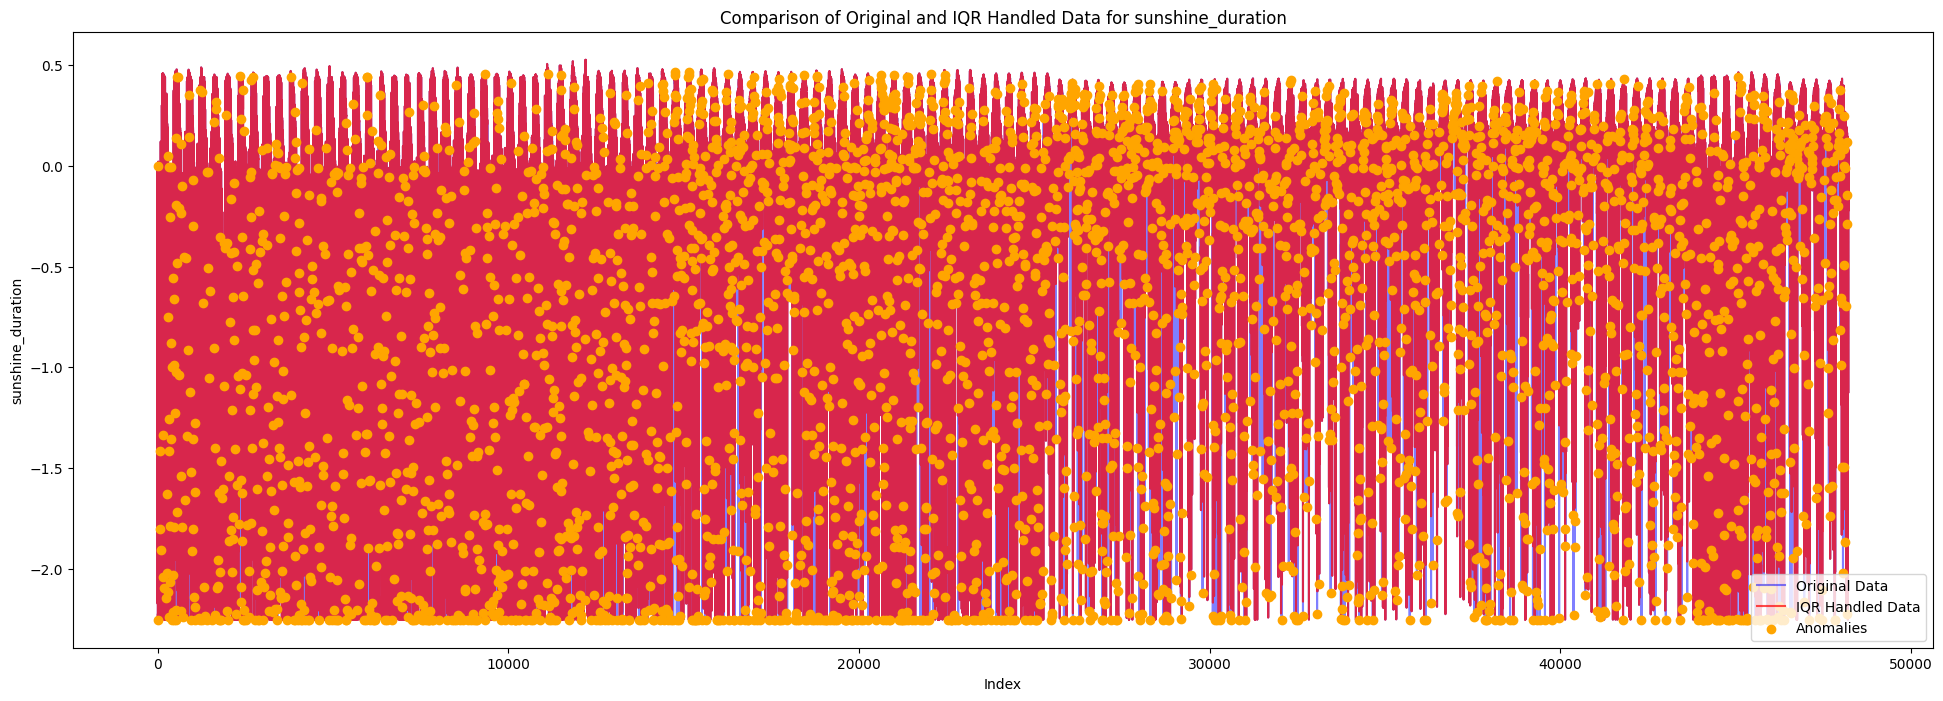

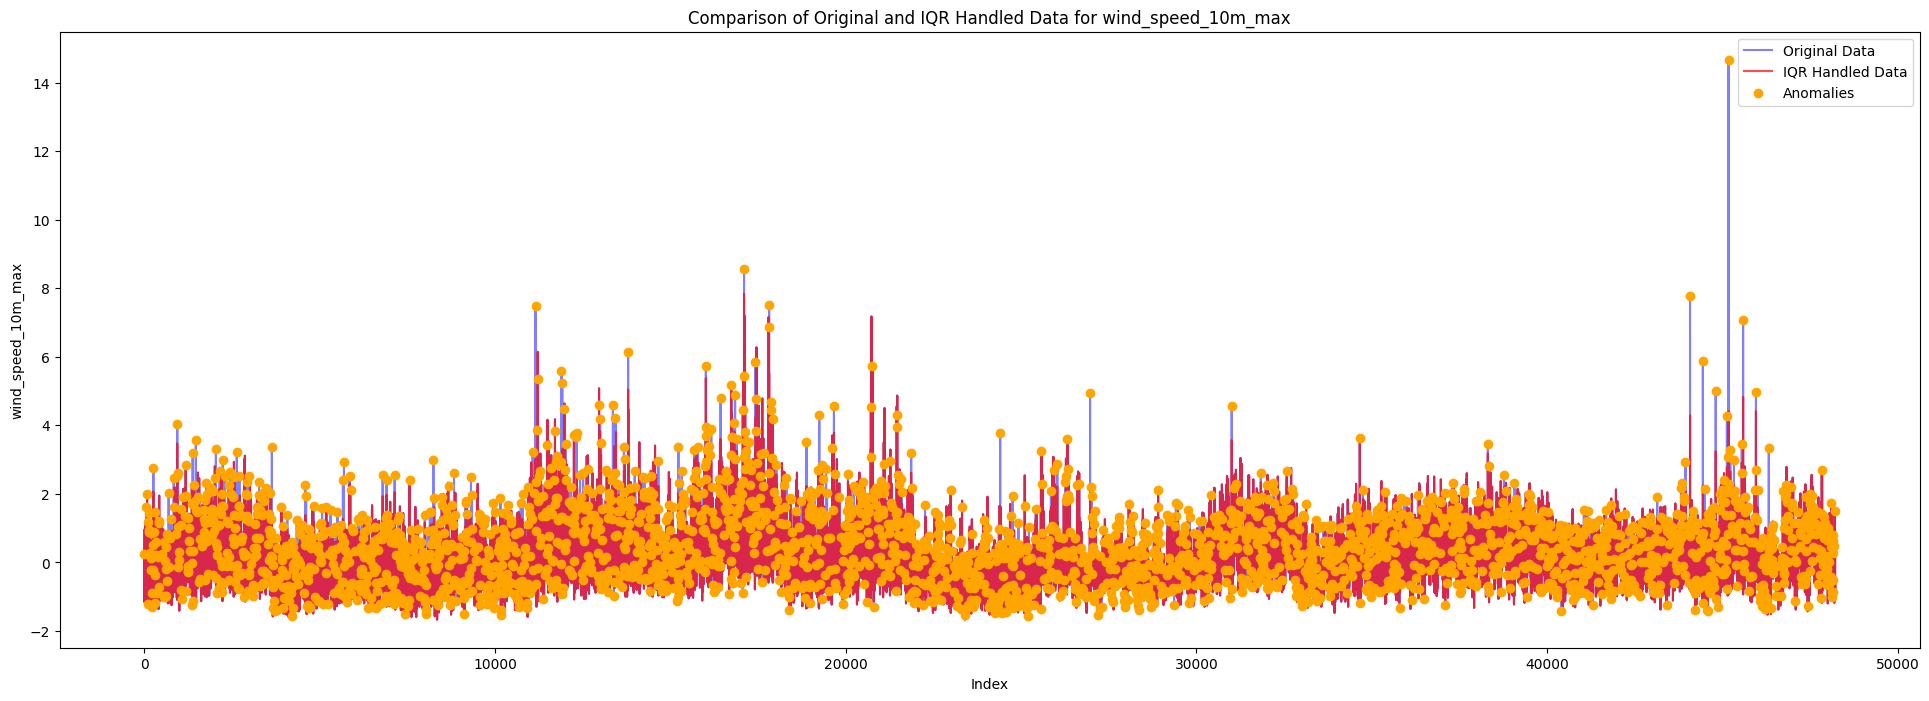

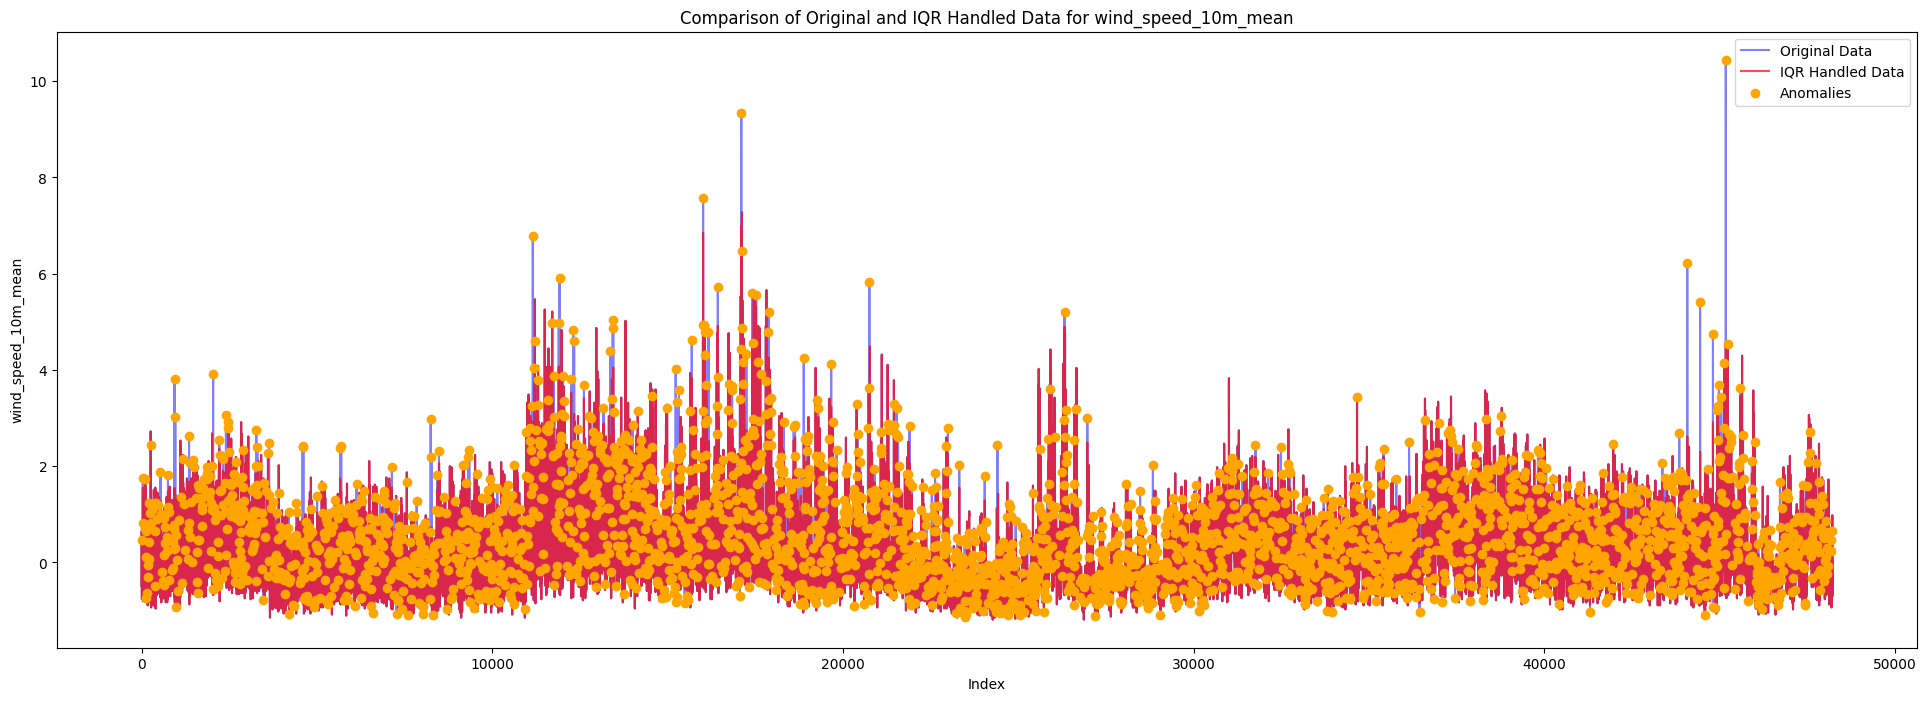

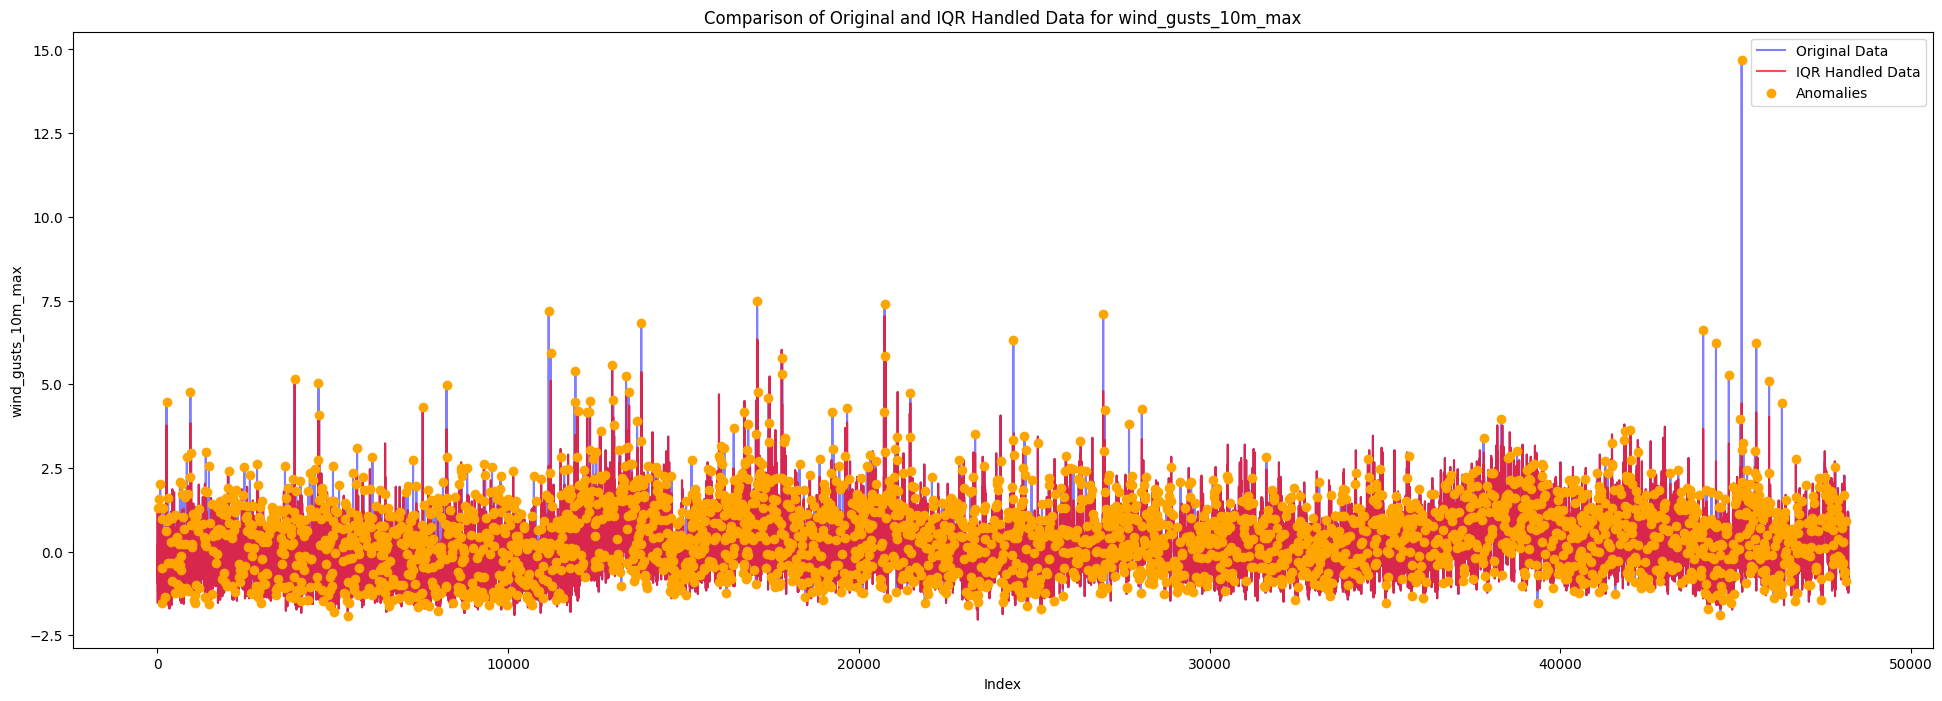

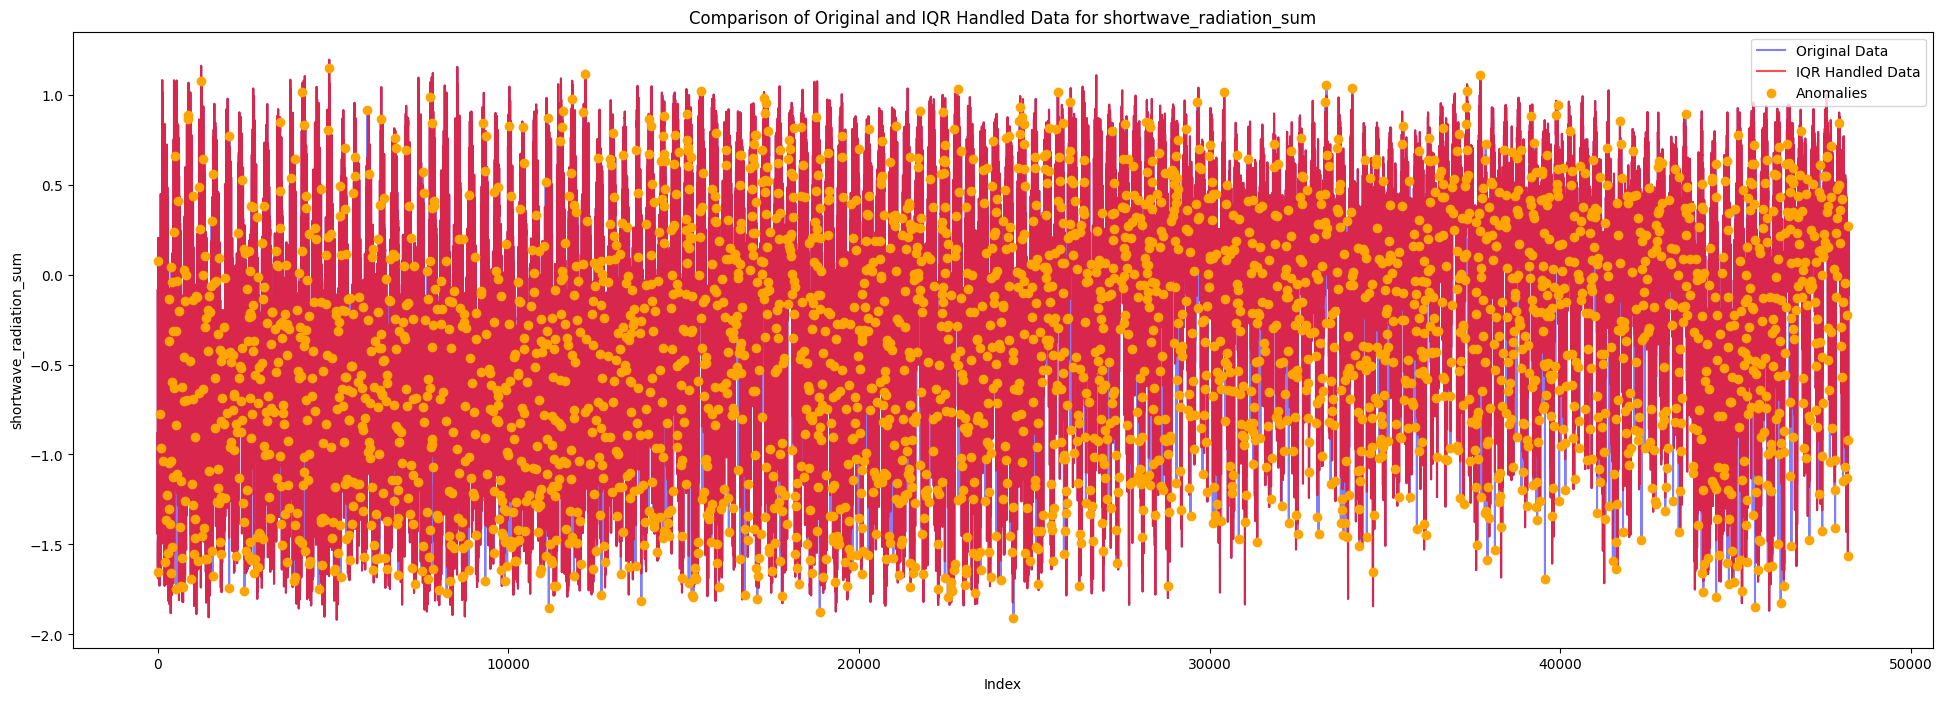

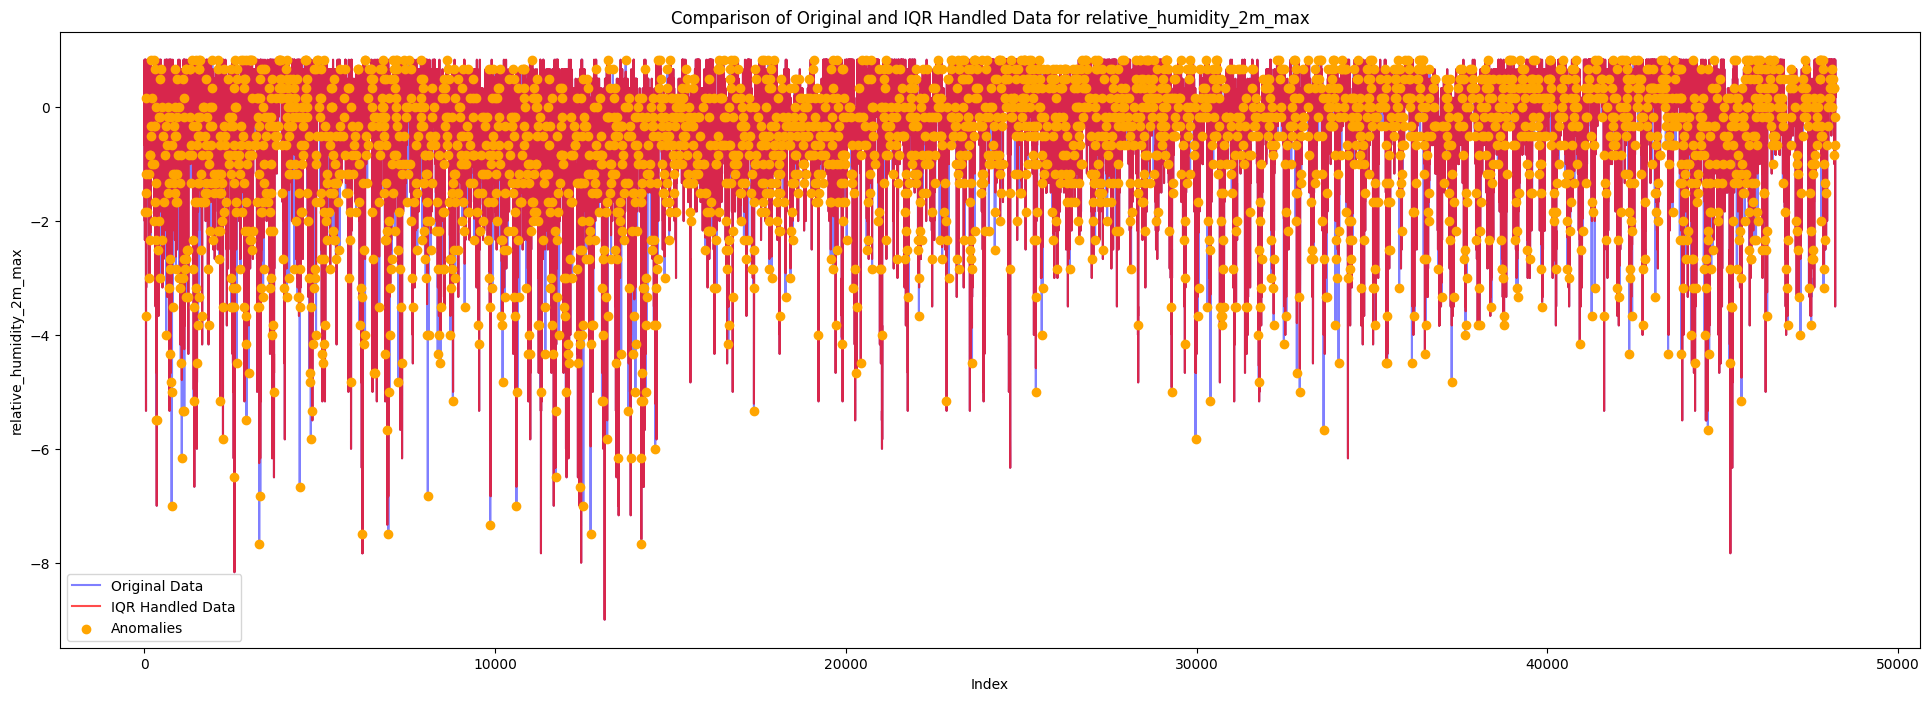

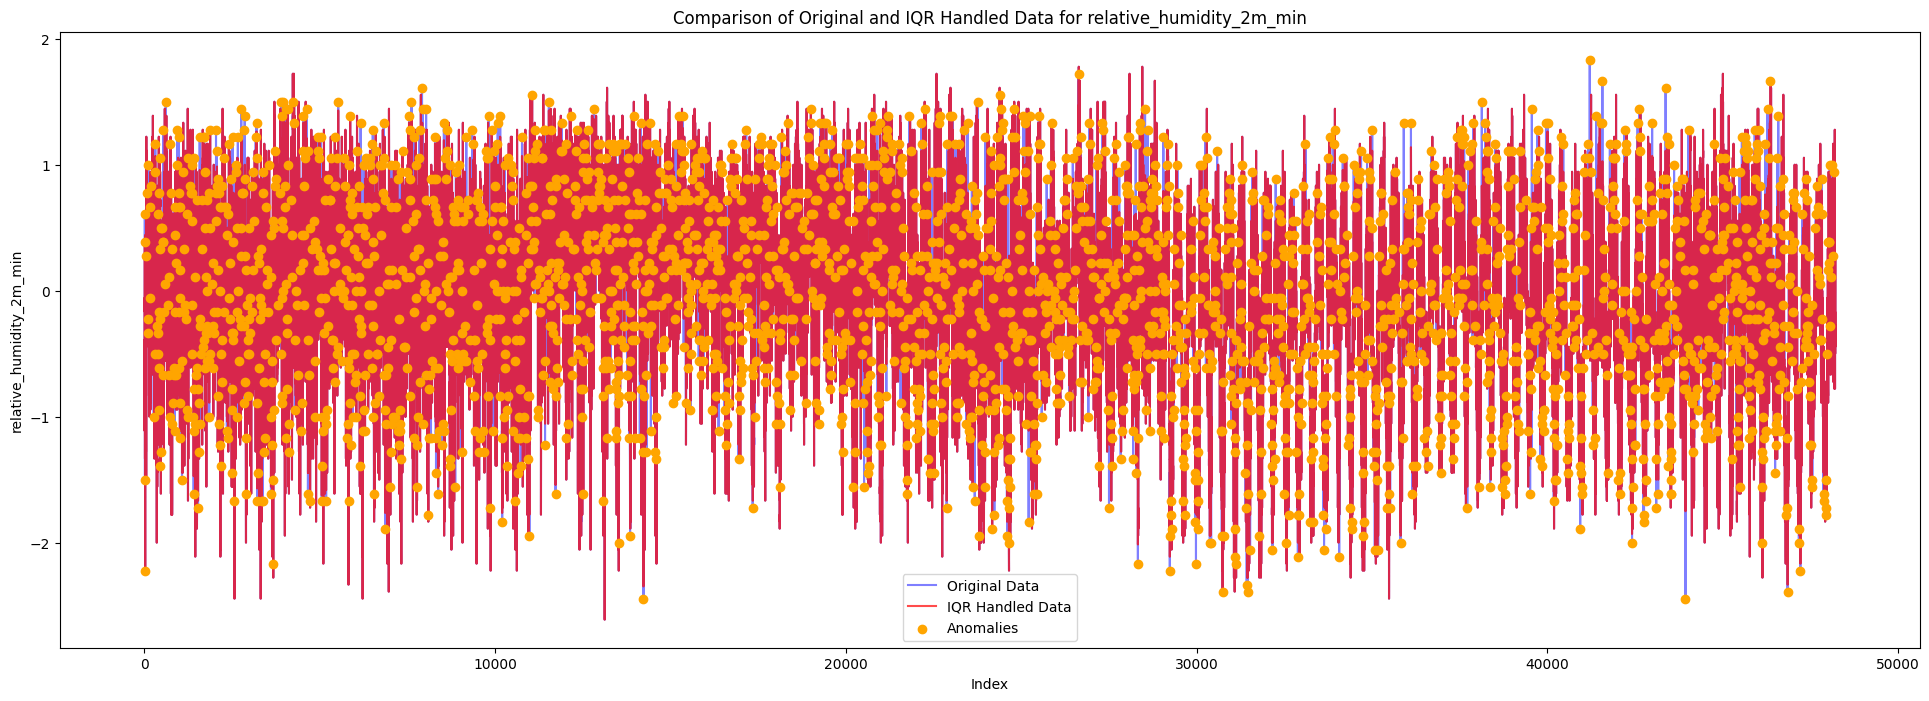

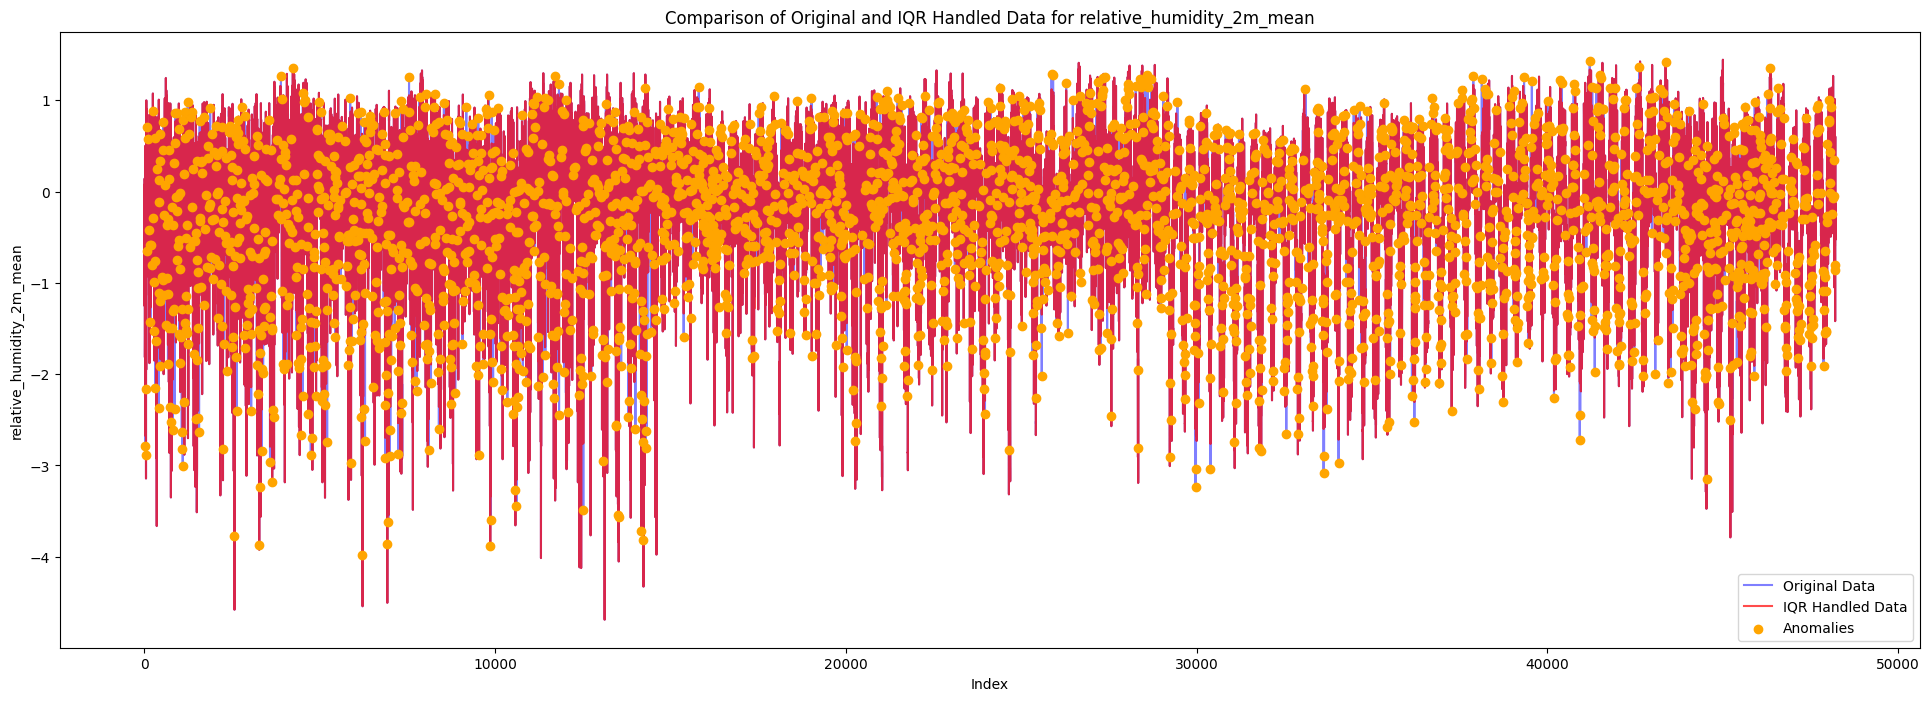

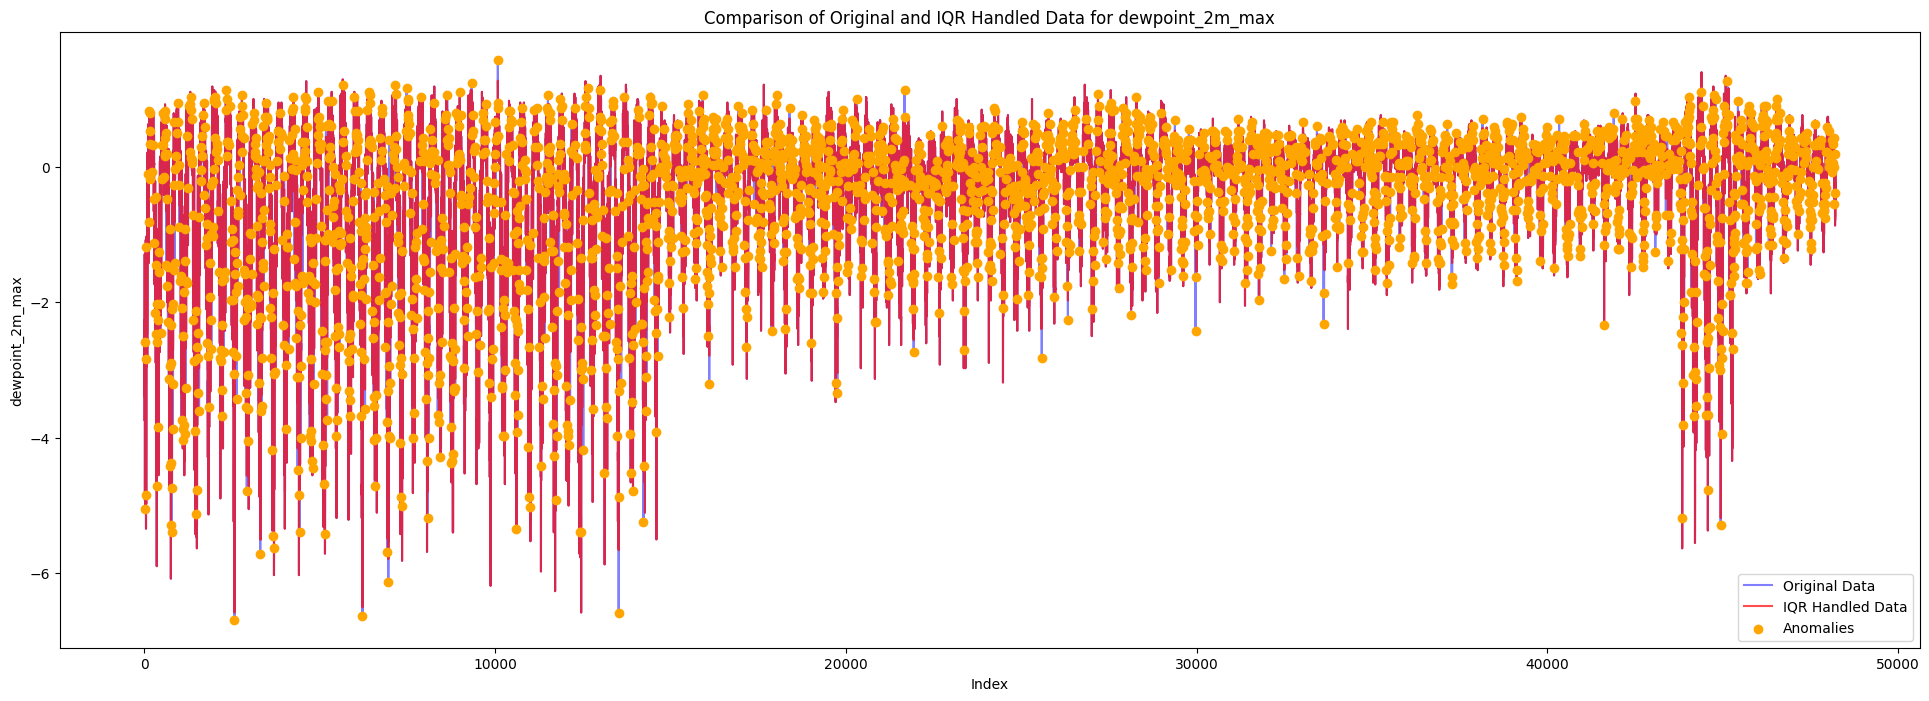

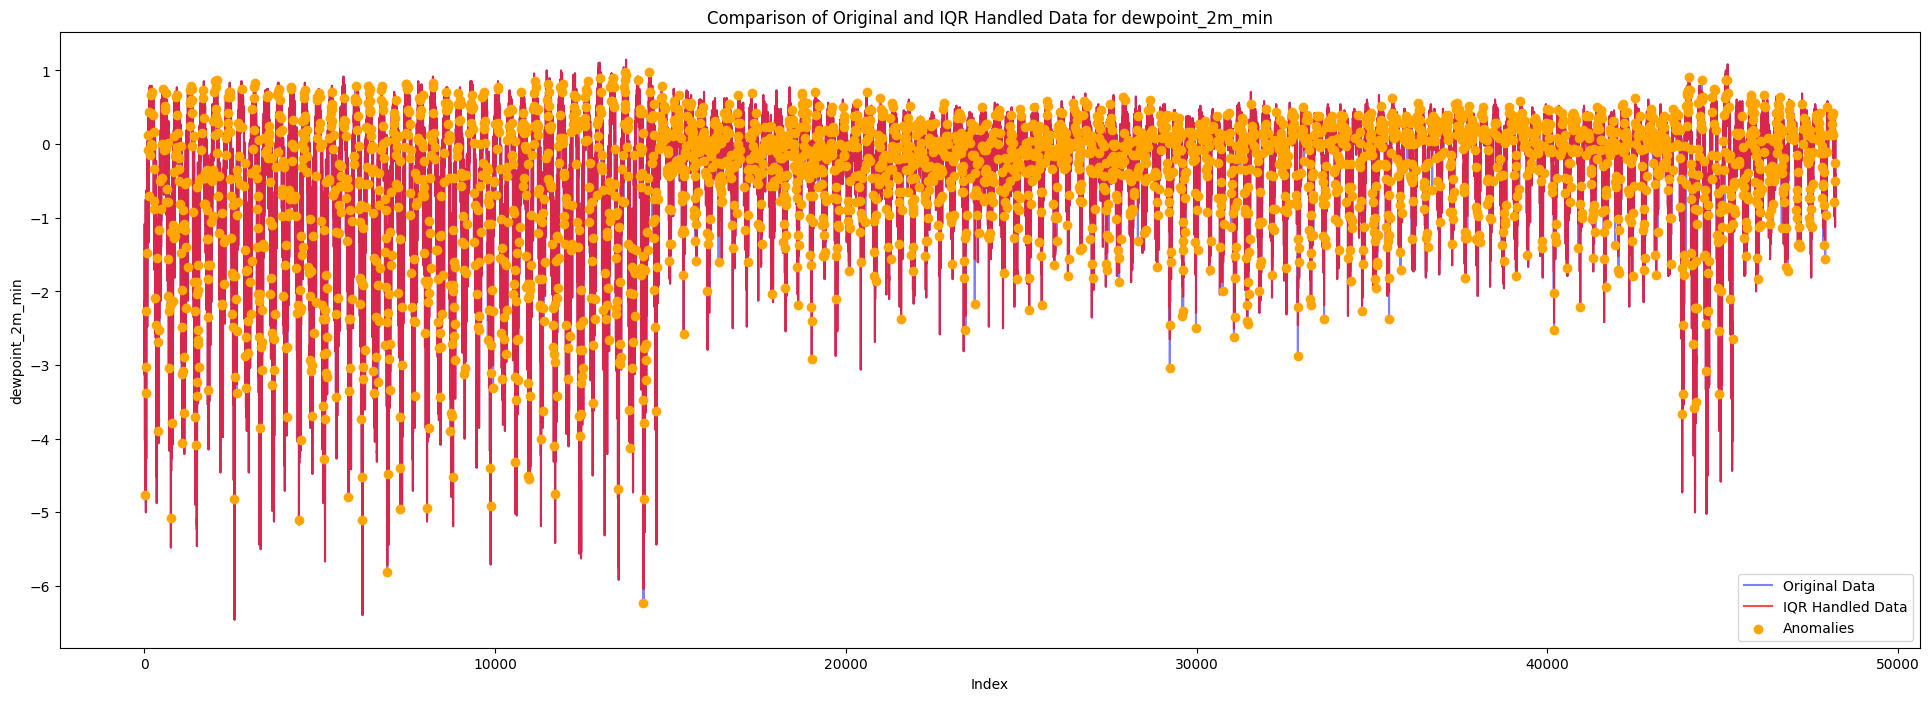

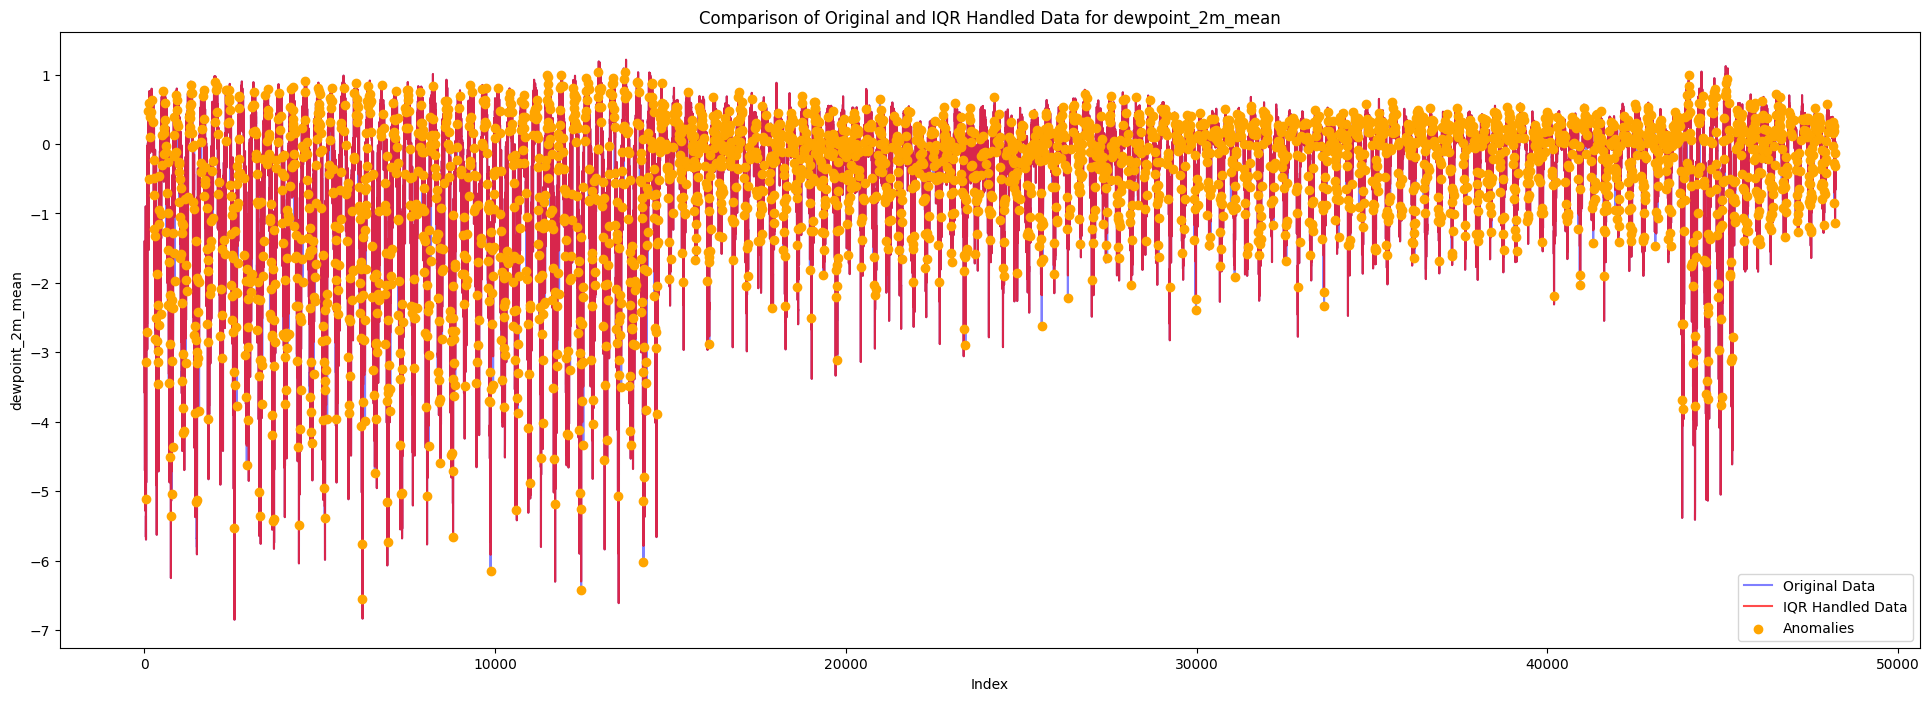

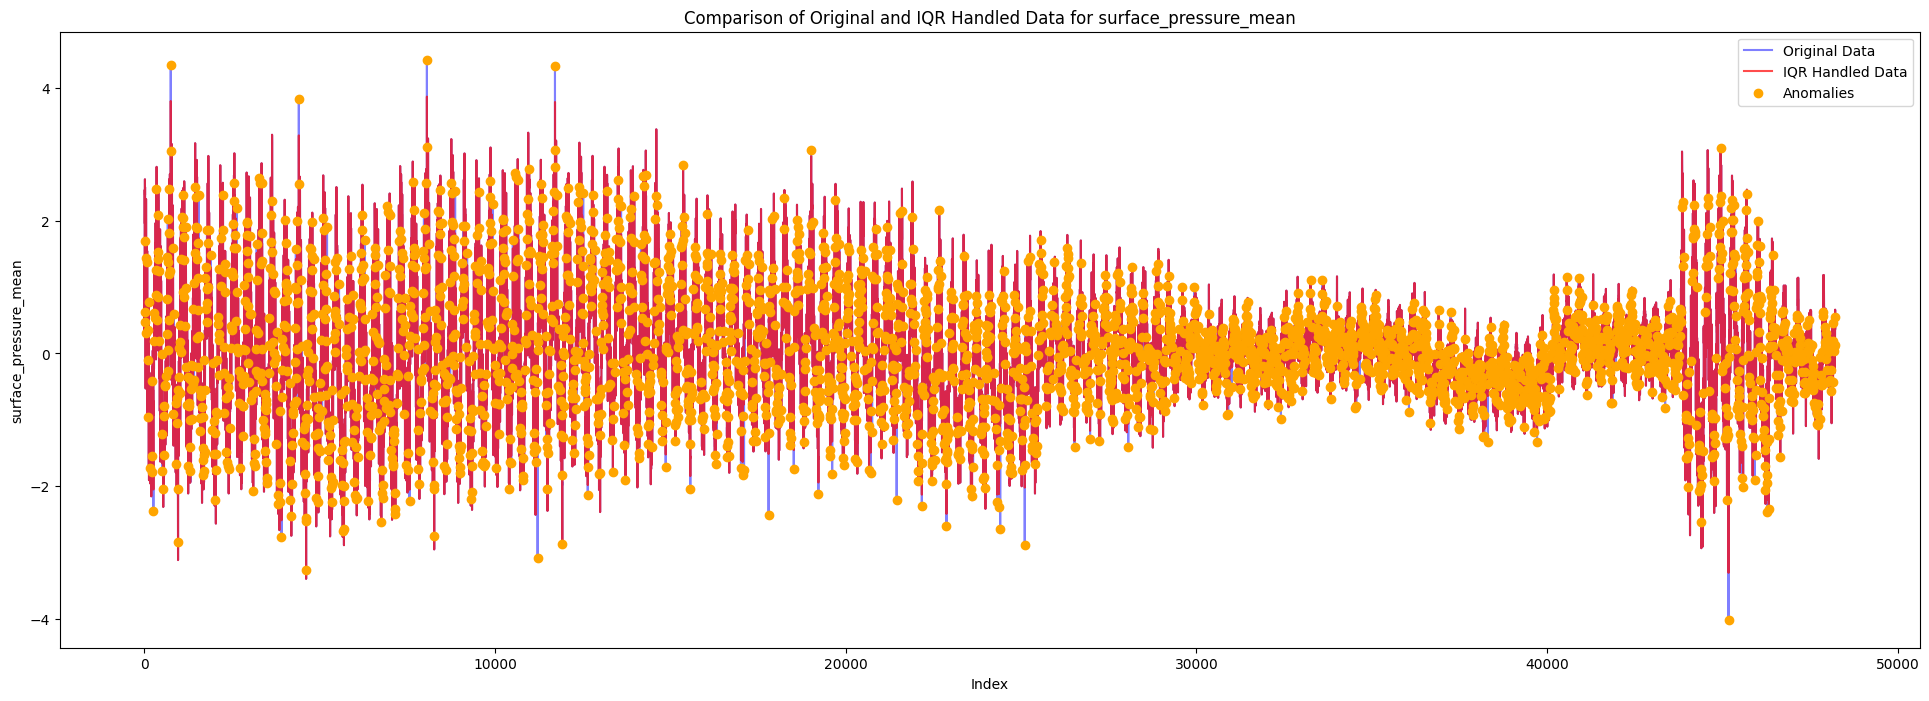

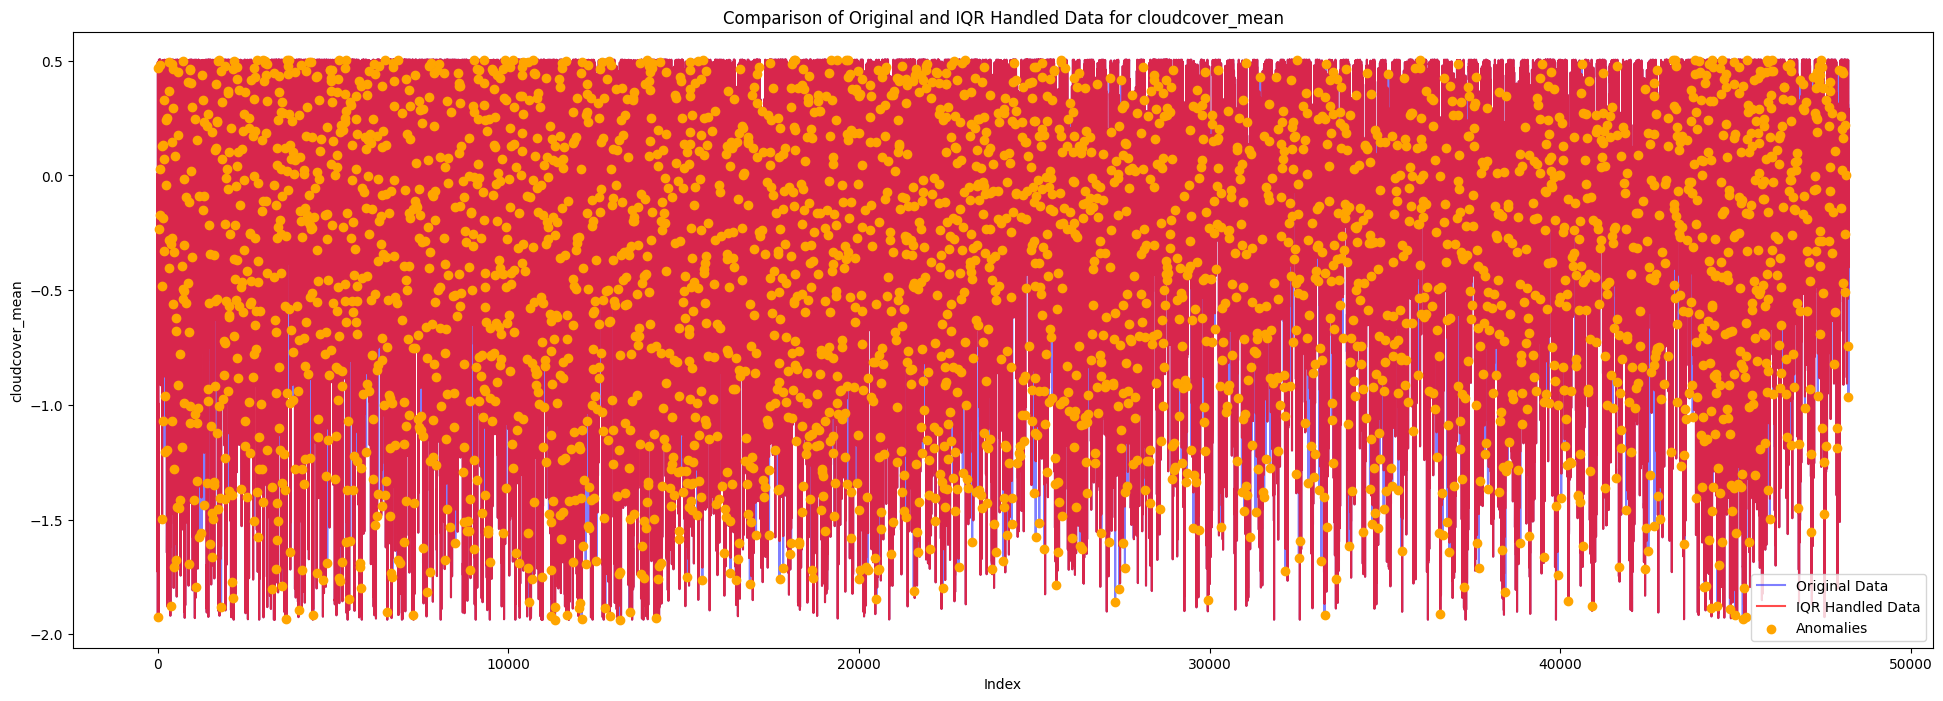

In [14]:
def Line_IQR_Change(old_data, new_data, col_name):
    plt.figure(figsize=(24, 8))
    plt.plot(old_data.index, old_data.values, label='Original Data', color='blue', alpha=0.5)
    plt.plot(new_data.index, new_data.values, label='IQR Handled Data', color='red', alpha=0.7)
    plt.scatter(anomaly_dict[col_name].index, anomaly_dict[col_name].values, color='orange', label='Anomalies', zorder=5)
    plt.title(f'Comparison of Original and IQR Handled Data for {col_name}')
    plt.xlabel('Index')
    plt.ylabel(col_name)
    plt.legend()
    plt.show()

for col in outlier:
    Line_IQR_Change(df_scaler[col], df_iqr[col], col)

### Feature Extraction

In [15]:
# Thay đổi các giá trị date thành ngày tháng năm
df_feature = df_iqr.copy()
df_feature['year'] = df_feature['date'].dt.year
df_feature['month'] = df_feature['date'].dt.month
df_feature['day'] = df_feature['date'].dt.day
df_feature['dayofweek'] = df_feature['date'].dt.dayofweek
df_feature['quarter'] = df_feature['date'].dt.quarter
df_feature['dayinmonth'] = df_feature['date'].dt.days_in_month
# df_feature = df_feature.drop(columns=['date'])

In [16]:
# Kỹ thuật Cyclical Feature Encoding
month_max = 12
week_day_max = 7
df_feature['month_sin'] = np.sin(2 * np.pi * df_feature['month'] / month_max)
df_feature['month_cos'] = np.cos(2 * np.pi * df_feature['month'] / month_max)
df_feature['day_sin'] = np.sin(2 * np.pi * df_feature['day'] / df_feature['dayinmonth'])
df_feature['day_cos'] = np.cos(2 * np.pi * df_feature['day'] / df_feature['dayinmonth'])
df_feature['dayofweek_sin'] = np.sin(2 * np.pi * df_feature['dayofweek'] / week_day_max)
df_feature['dayofweek_cos'] = np.cos(2 * np.pi * df_feature['dayofweek'] / week_day_max)
df_feature['quarter_sin'] = np.sin(2 * np.pi * df_feature['quarter'] / 4)
df_feature['quarter_cos'] = np.cos(2 * np.pi * df_feature['quarter'] / 4)

In [17]:
df_cycling = df_feature.drop(columns=['month', 'day', 'dayofweek', 'quarter', 'dayinmonth'])
df_cycling

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,cloudcover_mean,year,month_sin,month_cos,day_sin,day_cos,dayofweek_sin,dayofweek_cos,quarter_sin,quarter_cos
0,Hanoi,21.0278,105.8342,2014-01-01,-2.000000,-4.351351,-3.405405,0.000,0.0,0,...,-1.936435,2014,5.000000e-01,0.866025,2.012985e-01,0.979530,0.974928,-0.222521,1.000000e+00,6.123234e-17
1,Hanoi,21.0278,105.8342,2014-01-02,-1.469388,-3.756757,-2.891892,0.000,0.0,0,...,-1.499110,2014,5.000000e-01,0.866025,3.943559e-01,0.918958,0.433884,-0.900969,1.000000e+00,6.123234e-17
2,Hanoi,21.0278,105.8342,2014-01-03,-1.795918,-2.648649,-2.513514,0.400,3.0,1,...,0.009153,2014,5.000000e-01,0.866025,5.712682e-01,0.820763,-0.433884,-0.900969,1.000000e+00,6.123234e-17
3,Hanoi,21.0278,105.8342,2014-01-04,-1.693878,-2.837838,-2.540541,0.000,0.0,0,...,-1.007882,2014,5.000000e-01,0.866025,7.247928e-01,0.688967,-0.974928,-0.222521,1.000000e+00,6.123234e-17
4,Hanoi,21.0278,105.8342,2014-01-05,-1.408163,-3.513514,-2.675676,0.000,0.0,0,...,-1.727943,2014,5.000000e-01,0.866025,8.486443e-01,0.528964,-0.781831,0.623490,1.000000e+00,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48211,Long An,10.5336,106.4110,2024-12-27,0.102041,-0.162162,-0.135135,6.375,5.0,1,...,0.156623,2024,-2.449294e-16,1.000000,-7.247928e-01,0.688967,-0.433884,-0.900969,-2.449294e-16,1.000000e+00
48212,Long An,10.5336,106.4110,2024-12-28,-0.061224,-0.270270,-0.270270,6.300,7.0,1,...,0.150521,2024,-2.449294e-16,1.000000,-5.712682e-01,0.820763,-0.974928,-0.222521,-2.449294e-16,1.000000e+00
48213,Long An,10.5336,106.4110,2024-12-29,-0.061224,-0.675676,-0.324324,0.000,0.0,0,...,-0.401983,2024,-2.449294e-16,1.000000,-3.943559e-01,0.918958,-0.781831,0.623490,-2.449294e-16,1.000000e+00
48214,Long An,10.5336,106.4110,2024-12-30,0.020408,-0.878378,-0.351351,0.000,0.0,0,...,-0.383422,2024,-2.449294e-16,1.000000,-2.012985e-01,0.979530,0.000000,1.000000,-2.449294e-16,1.000000e+00


3. Feature Engineering

In [18]:
df_create = df_cycling.copy()
total_cols = df_create.select_dtypes(include=['float64', 'int64']).columns

In [19]:
total_cols

Index(['latitude', 'longitude', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'rain_sum', 'precipitation_hours',
       'weather_code', 'sunshine_duration', 'daylight_duration',
       'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_gusts_10m_max',
       'wind_direction_10m_dominant', 'shortwave_radiation_sum',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'relative_humidity_2m_mean', 'dewpoint_2m_max', 'dewpoint_2m_min',
       'dewpoint_2m_mean', 'surface_pressure_mean', 'cloudcover_mean',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofweek_sin',
       'dayofweek_cos', 'quarter_sin', 'quarter_cos'],
      dtype='object')

Tạo các lag feature và Rolling feature cho các feature bị biến động bởi thời gian:
temperature(min,max,mean), rain_sum(target), wind_speed(min,max,mean), relative_humidity(min,max,mean), dew_point(min,max,mean)

Bởi vì nếu tạo cho tất cả min,max,mean sẽ bị bùng nổ hàng nên ưu tiên tạo cho mean

In [20]:
cols = ["rain_sum", "temperature_2m_mean", "relative_humidity_2m_mean", "wind_speed_10m_mean", "dewpoint_2m_mean"]
target_cols = ["rain_sum", "weather_code", "precipitation_hours"]
dynamic_cols = ['temperature_2m_mean', 
    'relative_humidity_2m_mean', 
    'dewpoint_2m_mean', 
    'surface_pressure_mean', 
    'cloudcover_mean', 
    'wind_speed_10m_mean']
cols_drop = ["sunrise", "sunset", "sunshine_duration", "daylight_duration", "wind_direction_10m_dominant", "shortwave_radiation_sum","temperature_2m_max", "temperature_2m_min",
    "wind_speed_10m_max", "wind_gusts_10m_max",
    "relative_humidity_2m_max", "relative_humidity_2m_min",
    "dewpoint_2m_max", "dewpoint_2m_min"]


In [21]:
lags_target = [1,2,3,7]
window_rolling_target = [3,7]
lags_dynamic = [1,2]
window_rolling_dynamic = [3]


In [22]:
df_create = df_create.drop(columns=cols_drop)
df_create.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48216 entries, 0 to 48215
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   city                       48216 non-null  object        
 1   latitude                   48216 non-null  float64       
 2   longitude                  48216 non-null  float64       
 3   date                       48216 non-null  datetime64[ns]
 4   temperature_2m_mean        48216 non-null  float64       
 5   rain_sum                   48216 non-null  float64       
 6   precipitation_hours        48216 non-null  float64       
 7   weather_code               48216 non-null  int64         
 8   wind_speed_10m_mean        48216 non-null  float64       
 9   relative_humidity_2m_mean  48216 non-null  float64       
 10  dewpoint_2m_mean           48216 non-null  float64       
 11  surface_pressure_mean      48216 non-null  float64       
 12  clou

In [23]:
for lag in lags_target:
    for col in target_cols:
        df_create[f'{col}_lag_{lag}'] = df_create.groupby('city')[col].shift(lag)

for window in window_rolling_target:
    for col in target_cols:
        df_create[f'{col}_rolling_mean_{window}'] = df_create.groupby('city')[col].transform(lambda x: x.rolling(window, min_periods=1).mean())

In [24]:
for lag in lags_dynamic:
    for col in dynamic_cols:
        df_create[f'{col}_lag_{lag}'] = df_create.groupby('city')[col].shift(lag)

for window in window_rolling_dynamic:
    for col in dynamic_cols:
        df_create[f'{col}_rolling_mean_{window}'] = df_create.groupby('city')[col].transform(lambda x: x.rolling(window, min_periods=1).mean())

In [25]:
df_create.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48216 entries, 0 to 48215
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   city                                      48216 non-null  object        
 1   latitude                                  48216 non-null  float64       
 2   longitude                                 48216 non-null  float64       
 3   date                                      48216 non-null  datetime64[ns]
 4   temperature_2m_mean                       48216 non-null  float64       
 5   rain_sum                                  48216 non-null  float64       
 6   precipitation_hours                       48216 non-null  float64       
 7   weather_code                              48216 non-null  int64         
 8   wind_speed_10m_mean                       48216 non-null  float64       
 9   relative_humidity_2m_mean   

In [26]:
df_create = df_create.dropna().reset_index(drop=True)

In [27]:
df_create.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48132 entries, 0 to 48131
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   city                                      48132 non-null  object        
 1   latitude                                  48132 non-null  float64       
 2   longitude                                 48132 non-null  float64       
 3   date                                      48132 non-null  datetime64[ns]
 4   temperature_2m_mean                       48132 non-null  float64       
 5   rain_sum                                  48132 non-null  float64       
 6   precipitation_hours                       48132 non-null  float64       
 7   weather_code                              48132 non-null  int64         
 8   wind_speed_10m_mean                       48132 non-null  float64       
 9   relative_humidity_2m_mean   

In [28]:
from sklearn.preprocessing import LabelEncoder
le_city = LabelEncoder()
df_create['city'] = le_city.fit_transform(df_create['city'])
df_create['city'].unique()


array([ 3, 10, 11,  9,  1,  5,  8,  6,  4,  2,  0,  7])

In [29]:
df_create.to_csv("../data/processed/data_processed.csv", index=False)

In [30]:
df_create['weather_code'].unique()

array([1, 0], dtype=int64)

In [31]:
df_create['rain_sum'].describe()

count    48132.000000
mean         5.221418
std          9.308814
min          0.000000
25%          0.000000
50%          1.350000
75%          6.606250
max        178.900000
Name: rain_sum, dtype: float64